<p>
    <a href="https://umt.edu.al/en/anxhelo-shehu/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2022/10/Anxhelo-Shehu-min-2-300x300.jpg" width="150" alt="UMT Logo">
    </a>
</p>
<p>
    <a href="https://umt.edu.al/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2024/11/Universiteti-Metropolitan-Tirana.webp" width="200" alt="UMT Logo">
    </a>
</p>

<h1> Segmentimi: </h1>

Koha e nevojshme per kete Lab: **+60** minuta


## Basic Edge Detection by Using First-Order Derivative

Detektimi i skajeve (edge detection) bazuar në derivatin e rendit të parë mbështetet në konceptin e **gradientit** të imazhit. Skajet korrespondojnë me zona ku ka ndryshime të forta të intensitetit.

### Përkufizimi i gradientit

Për një imazh $ f(x, y) $, gradienti përcaktohet si:
$$
\nabla f = \left[ \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right]
$$

ku:
- $ \frac{\partial f}{\partial x} $ është ndryshimi në drejtimin horizontal  
- $ \frac{\partial f}{\partial y} $ është ndryshimi në drejtimin vertikal  

### Magnituda dhe drejtimi i gradientit

Magnituda e gradientit jep forcën e skajit:

$$
M(x,y) = \sqrt{G_x^2 + G_y^2}
$$

Një formë e thjeshtuar është:

$$
M(x,y) \approx |G_x| + |G_y|
$$

Drejtimi i gradientit është:

$$
\theta(x,y) = \tan^{-1}\left(\frac{G_y}{G_x}\right)
$$

### Interpretimi

- Vlera të larta të $ M(x,y) $ tregojnë praninë e një skaji  
- Drejtimi $ \theta $ tregon orientimin e skajit  
- Skajet ndodhen në zona me ndryshim të madh të intensitetit  

### Implementimi praktik

Në praktikë, derivatet llogariten duke përdorur **filtra diskretë**, si:
- Roberts  
- Prewitt  
- Sobel  

Këto operatorë janë aproksimime të derivatit të parë dhe aplikohen përmes konvolucionit mbi imazhin.

### Përfundim

Metodat e bazuara në derivatin e rendit të parë janë:
- të thjeshta për implementim  
- efikase për detektimin e skajeve  
- baza për algoritme më të avancuara si **Canny Edge Detector**

Shkarkojme  disa nga imazhet e nevojshme per kete laborator


In [13]:
import requests

# URLs per imazhet
urls = [
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg"
]

# Shkarkojme edhe ruajm imazhet duke perdorur URL perkatese
for url in urls:
    response = requests.get(url)
    if response.status_code == 200:
        filename = url.split("/")[-1]
        with open(filename, 'wb') as file:
            file.write(response.content)
        print(f"Downloaded: {filename}")
    else:
        print(f"Failed to download: {url}")

Downloaded: lenna.png
Downloaded: barbara.png
Downloaded: cameraman.jpeg


Ne importojme librarit e nevojshme

In [15]:
# Përdoret për të shfaqur imazhet
import matplotlib.pyplot as plt
# Përdoret për të ngarkuar një imazh
from PIL import Image
# Përdoret për të krijuar bërthama për filtrimin
import numpy as np
# Përdoret për të ngarkuar një imazh dhe per te kryer operacione mbi te (aplikimi i kernelit mbi imazh)
import cv2

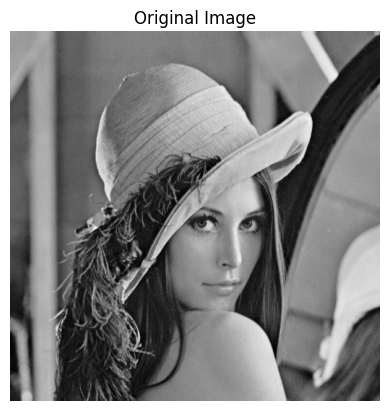

In [16]:

def show(img, title="Image"):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Ngarko imazhin (grayscale)
img = cv2.imread('lenna.png', 0)
show(img, "Original Image")

#### Roberts Operator

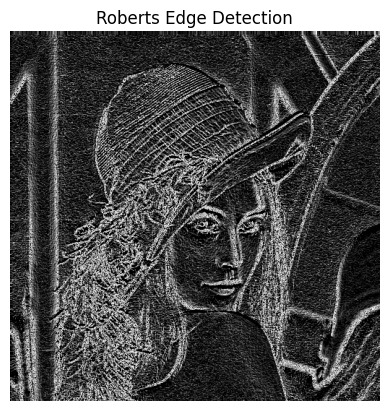

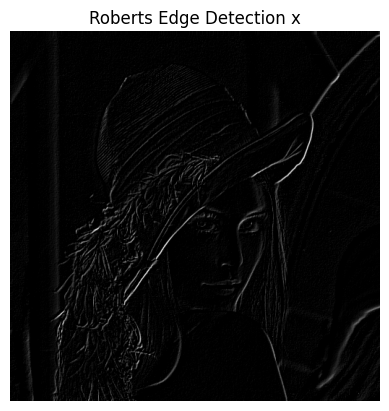

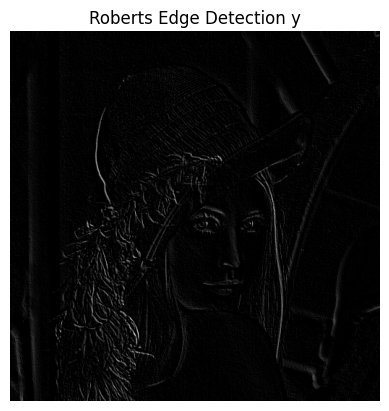

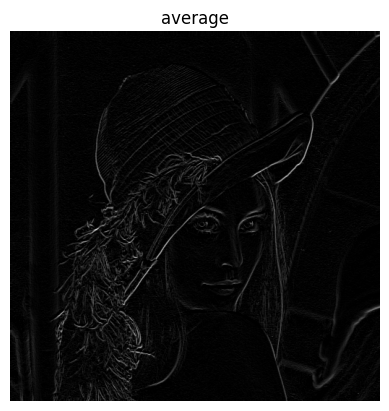

In [20]:
# Roberts kernels
kernelx = np.array([[1, 0],
                    [0, -1]])

kernely = np.array([[0, 1],
                    [-1, 0]])

robertsx = cv2.filter2D(img, -1, kernelx)
robertsy = cv2.filter2D(img, -1, kernely)

roberts = np.sqrt(robertsx**2 + robertsy**2)

show(roberts, "Roberts Edge Detection")
show(robertsx, "Roberts Edge Detection x")
show(robertsy, "Roberts Edge Detection y")
show((robertsx+robertsy)/2, "average")


#### Prewitt Operator

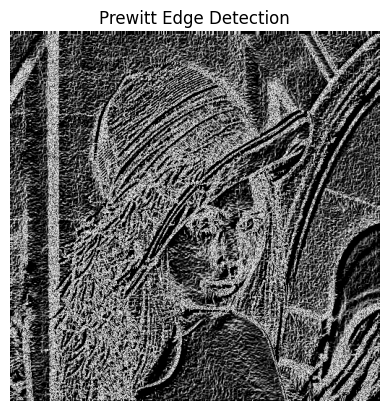

In [21]:
# Prewitt kernels
kernelx = np.array([[1, 0, -1],
                    [1, 0, -1],
                    [1, 0, -1]])

kernely = np.array([[1, 1, 1],
                    [0, 0, 0],
                    [-1, -1, -1]])

prewittx = cv2.filter2D(img, -1, kernelx)
prewitty = cv2.filter2D(img, -1, kernely)

prewitt = np.sqrt(prewittx**2 + prewitty**2)

show(prewitt, "Prewitt Edge Detection")

#### Sobel Operator

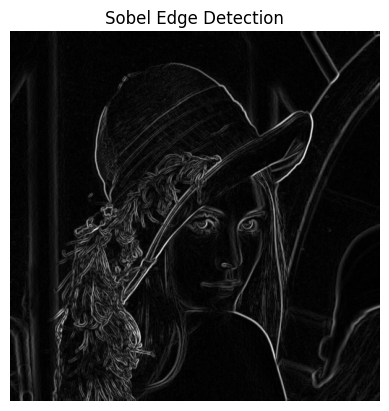

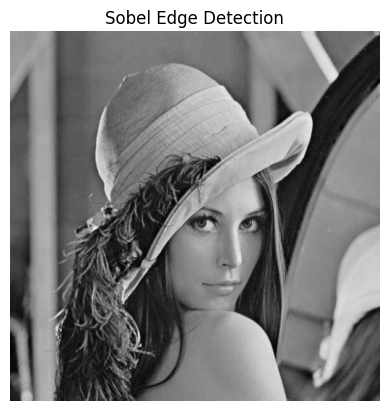

In [30]:
# Sobel operator (built-in OpenCV)
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

sobel = np.sqrt(sobelx**2 + sobely**2)

show(sobel, "Sobel Edge Detection")
im = img + sobel*0.05
show(im, "Sobel Edge Detection")

In [26]:
sobel

array([[  0.        ,   4.        ,   8.        , ...,  64.        ,
        148.        ,   0.        ],
       [  0.        ,   4.        ,   8.        , ...,  64.        ,
        148.        ,   0.        ],
       [  0.        ,   4.        ,   8.        , ...,  64.        ,
        148.        ,   0.        ],
       ...,
       [ 12.        ,  26.30589288,  24.69817807, ...,  18.43908891,
         34.05877273,  44.        ],
       [  0.        ,  39.3192065 ,  32.31098884, ...,  13.03840481,
         26.07680962,  28.        ],
       [  0.        ,  44.        ,  32.        , ...,  12.        ,
         20.        ,   0.        ]])

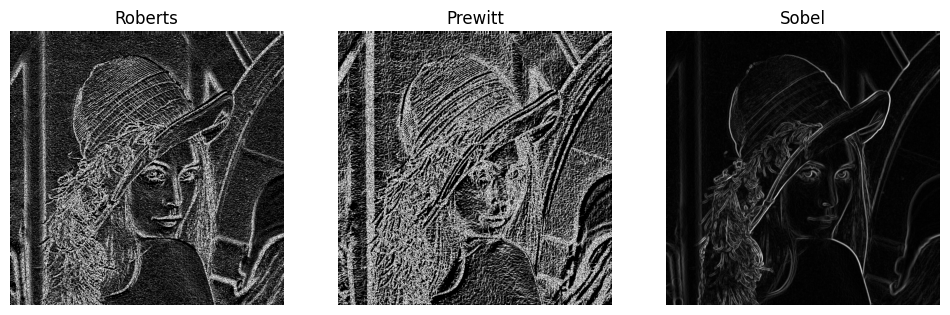

In [31]:
### Krahasimi
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(roberts, cmap='gray')
plt.title("Roberts")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.show()

# Marr-Hildreth Edge Detector

**Marr-Hildreth algorithm** është një metodë klasike për zbulimin e skajeve në një imazh.  
Ajo përdor **Laplacian of Gaussian (LoG)** për të identifikuar ndryshimet e mëdha të intensitetit të pixelëve.

## Hapat kryesorë të algoritmit

1. **Zbutja e imazhit me Gaussian (Gaussian Blur)**  

$$
G(x, y) = \frac{1}{2 \pi \sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}
$$

- Ku $\sigma $ kontrollon shkallën e zbutjes.  
- Imazhi origjinal $I(x,y)$ filtrohet me këtë kernel:

$$
I_{blur}(x,y) = I(x,y) * G(x,y)
$$

2. **Llogarit Laplacian**  

$$
\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}
$$

- Laplaciani i imazhit të zbutur $I_{blur}$ jep **Laplacian of Gaussian (LoG)**:

$$
LoG(x, y) = \nabla^2 (I * G)
$$

3. **Zbulimi i zero-crossings**  

- Skajet identifikohen aty ku vlera e Laplacian kalon nga pozitive në negative:

$$
\text{Edge at } (x, y) \text{ if } LoG(x, y) \cdot LoG(x+1, y) < 0 \text{ or } LoG(x, y) \cdot LoG(x, y+1) < 0
$$

## Avantazhet dhe disavantazhet

**Avantazhet:**  
- Zbulon skaje të hollësishme dhe të qarta.  
- Kombinon zbutjen dhe zbulimin e skajeve në një hap të vetëm.

**Disavantazhet:**  
- I ndjeshëm ndaj zhurmës.  
- Ndonjëherë jep skaje më të gjerë dhe të paqarta.

## Përdorimi praktik

- Përdoret në përpunimin e imazheve mjekësore, vizion kompjuterik dhe detektim objektesh.  
- Zakonisht kombinohet Gaussian Blur + Laplacian + zero-crossings për rezultate më të sakta.

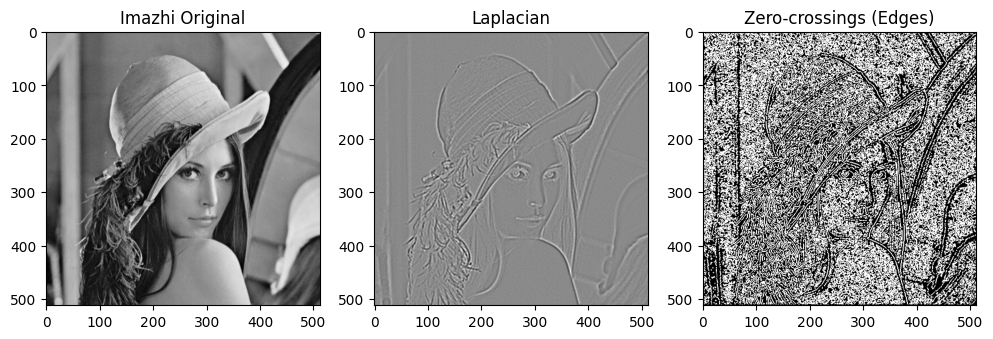

In [32]:

# Apliko Gaussian Blur
blurred = cv2.GaussianBlur(img, (5,5), 1.4)

# Apliko Laplacian
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)

# Gjej zero-crossings
zero_cross = np.zeros_like(laplacian)
zero_cross[1:-1,1:-1] = ((laplacian[1:-1,1:-1] * laplacian[:-2,1:-1] < 0) |
                         (laplacian[1:-1,1:-1] * laplacian[2:,1:-1] < 0) |
                         (laplacian[1:-1,1:-1] * laplacian[1:-1,:-2] < 0) |
                         (laplacian[1:-1,1:-1] * laplacian[1:-1,2:] < 0))

# Shfaq rezultatet
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.title('Imazhi Original')
plt.imshow(img, cmap='gray')

plt.subplot(1,3,2)
plt.title('Laplacian')
plt.imshow(laplacian, cmap='gray')

plt.subplot(1,3,3)
plt.title('Zero-crossings (Edges)')
plt.imshow(zero_cross, cmap='gray')

plt.show()

# Canny Edge Detector

**Canny Edge Detector** është një nga metodat më të njohura dhe të përdorura për detektimin e skajeve në imazhe.  
Zbulon skaje të hollësishme dhe redukton zhurmën në imazh.

## Hapat kryesorë të algoritmit

1. **Zbutja e imazhit (Gaussian Blur)**  
   - Redukton zhurmën që mund të shkaktojë skaje të rreme.

2. **Llogaritja e gradientit (Gradient Calculation)**  
   - Përdoret operator Sobel për të llogaritur intensitetin dhe drejtimin e gradientit në secilin pixel.
   - Gradienti i intensitetit:  
     $$
     G = \sqrt{G_x^2 + G_y^2}
     $$
     Drejtimi i gradientit:  
     $$
     \theta = \arctan\frac{G_y}{G_x}
     $$

3. **Non-maximum suppression**  
   - Ruajnë vetëm pikët që janë maksimum lokal në drejtim të gradientit, për të pastruar skajet e gabuara.

4. **Double thresholding (Dychotomous Thresholding)**  
   - Përcaktohen dy pragje: të lartë dhe të ulët.
   - Pikët me gradient mbi pragun e lartë konsiderohen si **strong edges**.  
   - Pikët me gradient midis pragut të ulët dhe të lartë konsiderohen si **weak edges**.

5. **Edge tracking by hysteresis**  
   - Weak edges që lidhen me strong edges mbeten. Të tjerat hiqen.

## Avantazhet
- Jep skaje të qarta dhe të hollësishme.  
- I qëndrueshëm ndaj zhurmës në imazh.

## Disavantazhet
- Ka parametra (sigma, thresholds) që duhet të zgjidhen mirë për rezultate optimale.

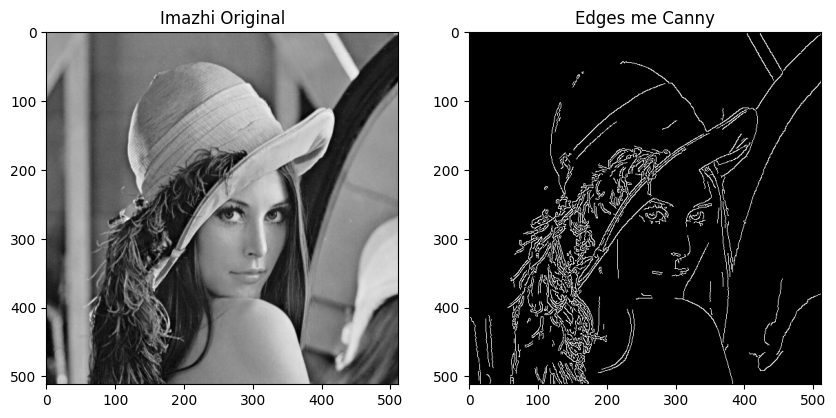

In [33]:

# Apliko Canny Edge Detector
edges = cv2.Canny(img, threshold1=100, threshold2=200)

# Shfaq imazhin origjinal dhe rezultatet
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imazhi Original')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Edges me Canny')
plt.imshow(edges, cmap='gray')

plt.show()

# Edge Linking and Boundary Detection

**Edge Linking** dhe **Boundary Detection** janë hapa të rëndësishëm pas detektimit të skajeve në përpunimin e imazheve.  
Qëllimi i tyre është të formojnë **kontura të plota** nga pikat e shpërndara të skajeve të zbuluara.

## 1. Edge Linking

- Pas detektimit të skajeve (p.sh., me Canny ose Marr-Hildreth), shpesh kemi **pikë të izoluara të skajeve**.
- **Edge Linking** përpiqet të lidhë këto pikat në vijë të vazhdueshme.
- Metodat kryesore për edge linking:
  1. **Pixel connectivity** – lidh pikat që janë fqinj me njëri-tjetrin (8-connexity ose 4-connexity).  
  2. **Edge following** – fillon nga pikët “strong” dhe ndjek drejtimin e gradientit për të ndjekur vijën e skajeve.
  3. **Hough Transform** – përdoret për të lidhur pikat që formojnë linja të drejta ose kurba të njohura.

## 2. Boundary Detection

- Pas edge linking, mund të formohen **boundary** ose **kontura të objektit**.
- Këto boundaries përdoren për:
  - Segmentim objektesh.
  - Njohje formash.
  - Analiza mjekësore (p.sh., konturimi i tumoreve ose organeve në imazhe).
- Shpesh përdoret një kombinim i **edge detection + edge linking + morphological operations** për të përmirësuar konturat.

## Përmbledhje

- **Edge Linking**: Lidh pikët e shpërndara të skajeve në vijë të vazhdueshme.  
- **Boundary Detection**: Formon kontura të plota të objekteve duke përdorur skajet e lidhura.  
- Këto hapa janë thelbësorë për segmentim dhe vizion kompjuterik.

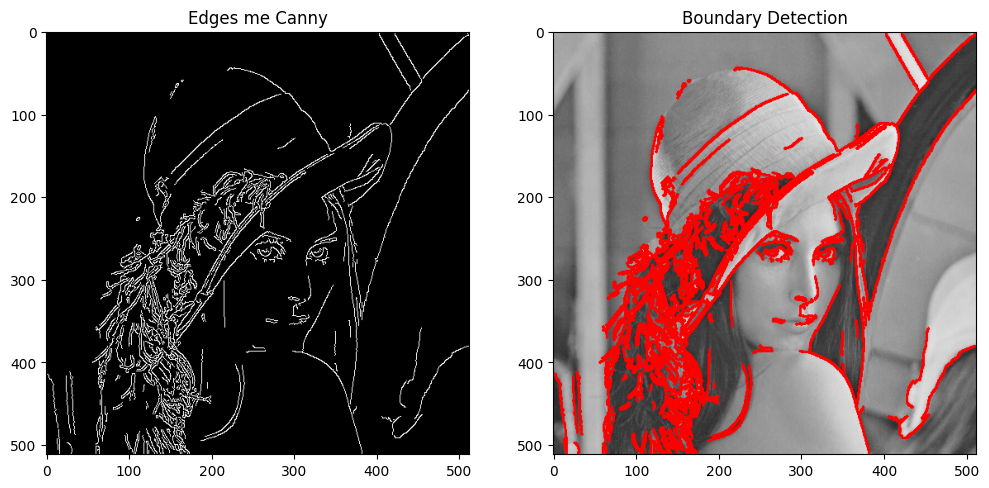

In [34]:

# Zbulimi i skajeve me Canny
edges = cv2.Canny(img, threshold1=100, threshold2=200)

# Gjej konturet (boundaries) nga skajet
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Krijo imazh bosh për vizualizim
img_contours = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_contours, contours, -1, (0,0,255), 2)  # vizaton me të kuqe

# Shfaq rezultatet
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Edges me Canny')
plt.imshow(edges, cmap='gray')

plt.subplot(1,2,2)
plt.title('Boundary Detection')
plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.show()

# Three Approaches to Edge Linking

Pas detektimit të skajeve, shpesh kemi **pikë të izoluara** që duhet të lidhen për të formuar vijë të vazhdueshme ose kontura të plota.  
Ekzistojnë tre qasje kryesore për **Edge Linking**:

---

## 1. Local Processing

- **Çfarë është:** Bazohet vetëm tek informacioni i afërt i një pixel-i.
- **Si funksionon:**  
  - Për çdo pixel të skajit, shikon fqinjësinë e tij (p.sh., 3x3 ose 5x5 window).  
  - Nëse fqinjët janë pjesë e skajit, lidhet me ta për të formuar vijë të vazhdueshme.
- **Avantazhet:**  
  - Shpejt dhe i thjeshtë për t’u implementuar.  
- **Disavantazhet:**  
  - Nuk kap vijat që janë të ndara me hapësira të vogla.  
  - Ndjeshëm ndaj zhurmës.

---

## 2. Regional Processing

- **Çfarë është:** Analizon një rajon më të madh të imazhit.
- **Si funksionon:**  
  - Përpiqet të lidhë skajet brenda një **rajoni të përcaktuar**, duke përdorur trajektore të mundshme të vijës ose rrugë të vazhdueshme.
- **Avantazhet:**  
  - Kap vijat më të gjata dhe mund të mbushë boshllëqe të vogla.  
- **Disavantazhet:**  
  - Më e ngadaltë se local processing.  
  - Mund të bëjë gabime në rajone me zhurmë të madhe.

---

## 3. Global Processing

- **Çfarë është:** Analizon të gjithë imazhin për të lidhur skajet.
- **Si funksionon:**  
  - Përdor informacione globale si **linja të drejta, kurba parametrike**, ose **model linear/global** për të ndërtuar kontura të plota.  
  - Shembull: **Hough Transform** përdoret për të lidhur pikat që formojnë linja të drejta.
- **Avantazhet:**  
  - Jep rezultate më të sakta për kontura komplekse dhe vijë të gjata.  
- **Disavantazhet:**  
  - Shumë më komplekse dhe më e ngadaltë për t’u implementuar.

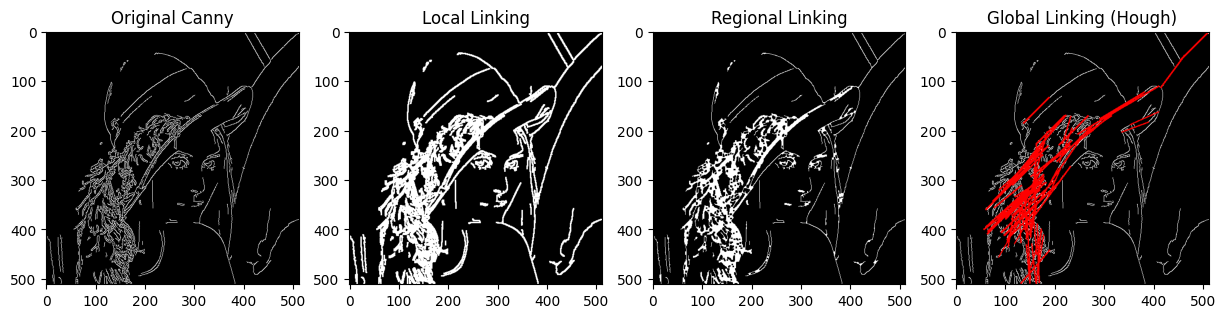

In [12]:

# 1. Zbulimi i skajeve fillestare me Canny
edges = cv2.Canny(img, 100, 200)

# 2. Local Processing: përdor dilatation për të lidhur pikët fqinj
kernel = np.ones((3,3), np.uint8)
edges_local = cv2.dilate(edges, kernel, iterations=1)

# 3. Regional Processing: përdor closing (dilatation + erosion) për të mbushur boshllëqet e vogla
edges_regional = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# 4. Global Processing: përdor Hough Transform për të lidhur linja të drejta
edges_global = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)  # nevojitet BGR për vizatim
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(edges_global, (x1,y1), (x2,y2), (0,0,255), 2)

# Shfaq të treja metodat
plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.title('Original Canny')
plt.imshow(edges, cmap='gray')

plt.subplot(1,4,2)
plt.title('Local Linking')
plt.imshow(edges_local, cmap='gray')

plt.subplot(1,4,3)
plt.title('Regional Linking')
plt.imshow(edges_regional, cmap='gray')

plt.subplot(1,4,4)
plt.title('Global Linking (Hough)')
plt.imshow(cv2.cvtColor(edges_global, cv2.COLOR_BGR2RGB))

plt.show()

# Referenca

[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<h3 align="center"> &#169; UMT. All rights reserved. <h3/>
    <h3 align="center"> anxheloshehu@umt.edu.al <h3/>